cuda


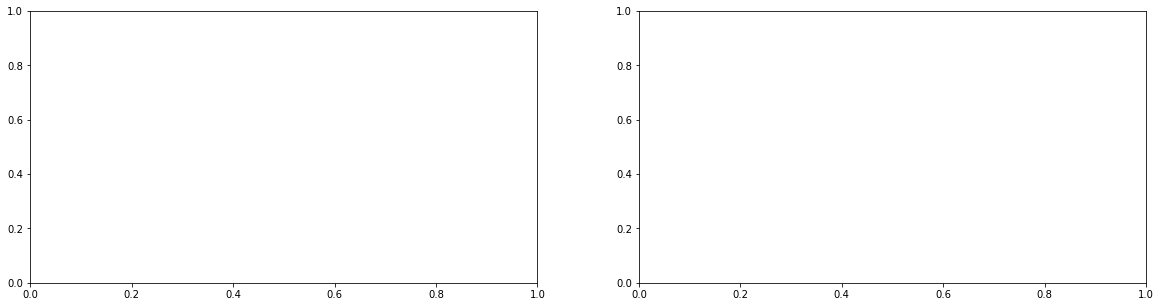

In [1]:
import os
import sys
import time
import copy
sys.path.append('../SLM/')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import json
import math
import random

import fnmatch
import re
from itertools import product, groupby

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from tokenizers import Tokenizer

import models, init, train, measures
import importlib
# Reload the modules
importlib.reload( models)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

def collect(path, prefix, *keys):

    all_entries = os.listdir(path)
    matching_entries = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
#                 params = re.findall(r'_P(\d+)', ending)
#                 assert params, f'{entry}: trainsize p not found!'
                array = re.findall(r'_(\d+)', ending)
                matching_entries.append({
                    'ending': ending,
#                     'P': int(params[0]),
                    'seed': int(array[0])
                })
#     matching_entries.sort(key=lambda x: [x.get('P'), x.get('exp')])
    return matching_entries


def find_all(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params


def find_lowest(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params[0]


def get_loss(path, prefix):

    loss_list = []

    p_list = find_all(path, prefix, 'P')
    print('training set sizes: ', p_list)

    for  p in p_list:

        bs = find_lowest(path, prefix, 'bs', f'P{p}_')
        print(f'P={p}, batch size={bs}')
        collection = collect( path, prefix, f'P{p}_', f'bs{bs}_')
        loss = []

        for entry in collection:
            try:
                results = torch.load(path+prefix+entry['ending'])
                print(p, results['best']['loss'])
                loss.append(results['best']['loss'])

            except:
                print(path+prefix+entry['ending']+f' not found.')


        print(f'{len(loss)} exps. , mean loss {torch.tensor(loss).mean()}')
        loss_list.append(torch.tensor(loss))
    return loss_list


fig, ax = plt.subplots(1, 2, figsize=(20,5.0))

768 1 1e-3 2.0 tensor(4.1109) tensor(0.0238)
768 1 1e-3 4.0 tensor(4.0868) tensor(0.0183)
768 1 1e-3 8.0 tensor(4.1128) tensor(0.0443)
768 1 3e-3 2.0 tensor(4.2006) tensor(0.0136)
768 1 3e-3 4.0 tensor(4.2570) tensor(0.0220)
768 1 3e-3 8.0 tensor(4.3603) tensor(0.0291)
768 2 3e-3 8.0 tensor(nan) tensor(nan)
768 2 3e-3 16.0 tensor(nan) tensor(nan)
768 2 3e-3 32.0 tensor(nan) tensor(nan)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=2$)')

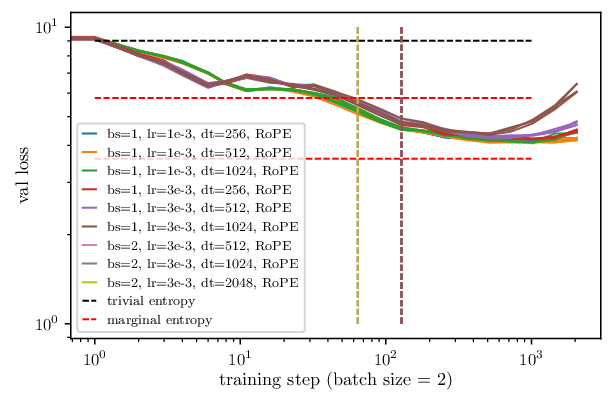

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 65536
path = f'tinystories/trained/T{T}_rope/P{P}/'

depth = 12
de = 768
nh = 12

bs = 1
for lr in [ '1e-3', '3e-3']:
    for dt in [256, 512, 1024]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{18}$

768 1 3e-4 2.0 tensor(3.4610) tensor(0.0473)
768 1 3e-4 4.0 tensor(3.3075) tensor(0.0201)
768 1 3e-4 8.0 tensor(3.2780) tensor(0.0059)
768 1 1e-3 2.0 tensor(3.3378) tensor(0.0169)
768 1 1e-3 4.0 tensor(3.1989) tensor(0.0240)
768 1 1e-3 8.0 tensor(3.2812) tensor(0.0245)
768 1 3e-3 2.0 tensor(3.4235) tensor(0.0370)
768 1 3e-3 4.0 tensor(3.4752) tensor(0.0324)
768 1 3e-3 8.0 tensor(3.5312) tensor(0.0377)
768 2 3e-3 2.0 tensor(3.3894) tensor(0.0390)
768 2 3e-3 4.0 tensor(3.3511) tensor(0.0334)
768 2 3e-3 8.0 tensor(3.4801) tensor(0.0317)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=2$)')

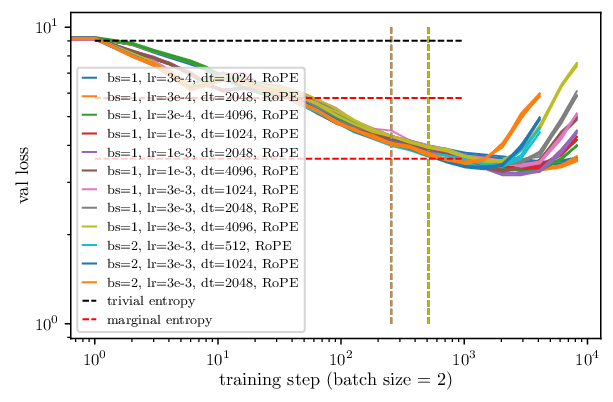

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 262144
path = f'tinystories/trained/T{T}_rope/P{P}/'

depth = 12
de = 768
nh = 12

bs = 1
for lr in ['3e-4', '1e-3', '3e-3']:
    for dt in [1024, 2048, 4096]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')

bs = 2
for lr in [ '3e-3']:
    for dt in [512, 1024, 2048]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{20}$

768 1 3e-4 2.0 tensor(2.6578) tensor(0.0155)
768 1 3e-4 4.0 tensor(2.5283) tensor(0.0149)
768 1 3e-4 8.0 tensor(2.6405) tensor(0.0163)
768 1 1e-3 2.0 tensor(2.5431) tensor(0.0088)
768 1 1e-3 4.0 tensor(2.5434) tensor(0.0154)
768 1 1e-3 8.0 tensor(2.6594) tensor(0.0078)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=1$)')

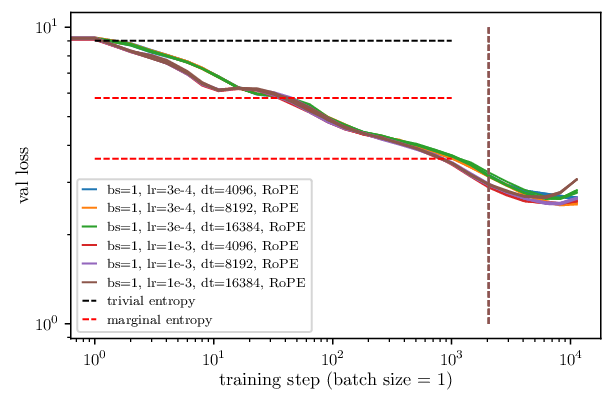

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 1048576
path = f'tinystories/trained/T{T}_rope/P{P}/'

depth = 12
de = 768
nh = 12

bs = 1
for lr in ['3e-4', '1e-3']:
    for dt in [4096, 8192, 16384]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{22}$

1024 1 3e-4 2.0 tensor(1.9980) tensor(0.0111)
1024 1 3e-4 4.0 tensor(1.9868) tensor(0.0047)
1024 1 3e-4 8.0 tensor(2.0787) tensor(0.0233)
1024 1 1e-3 2.0 tensor(2.0102) tensor(0.0115)
1024 1 1e-3 4.0 tensor(2.0554) tensor(0.0164)
1024 1 1e-3 8.0 tensor(2.0916) tensor(0.0127)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=1$)')

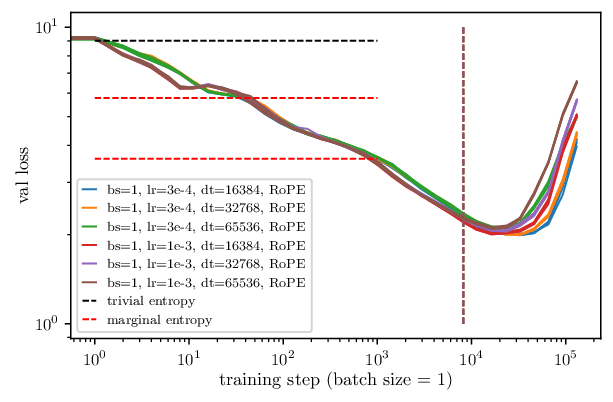

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 4194304
path = f'tinystories/trained/T{T}_rope/P{P}/'

depth = 12
de = 1024
nh = 16

bs = 1
for lr in ['3e-4', '1e-3']:
    for dt in [16384, 32768, 65536]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{24}$

1024 1 3e-4 2.0 tensor(1.6478) tensor(0.0029)
1024 1 3e-4 4.0 tensor(1.6263) tensor(0.0105)
1024 1 3e-4 8.0 tensor(1.6800) tensor(0.0058)
1024 1 1e-3 2.0 tensor(1.6897) tensor(0.0168)
1024 1 1e-3 4.0 tensor(1.6684) tensor(0.0096)
1024 1 1e-3 8.0 tensor(1.7090) tensor(0.0052)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=1$)')

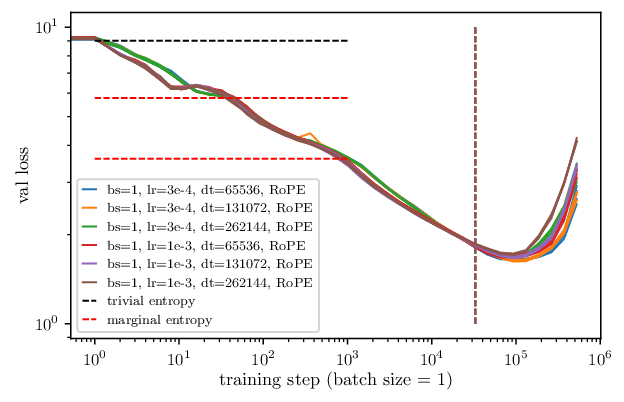

In [4]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 16777216
path = f'tinystories/trained/T{T}_rope/P{P}/'

depth = 12
de = 1024
nh = 16

bs = 1
for lr in ['3e-4', '1e-3']:
    for dt in [65536, 131072, 262144]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{26}$

1024 2 3e-4 4.0 tensor(1.3489) tensor(0.0073)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=2$)')

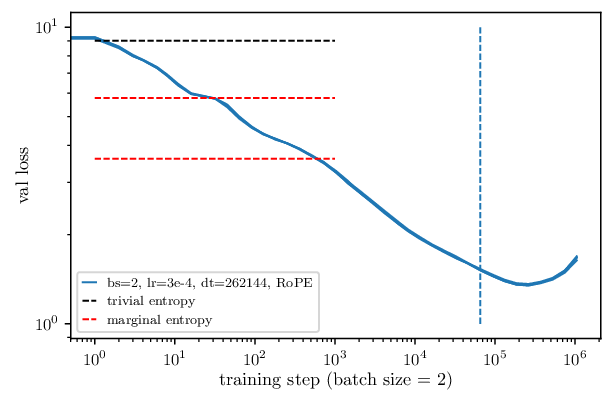

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 67108864
path = f'tinystories/trained/T{T}_rope/P{P}/'

depth = 12
de = 1024
nh = 16

bs = 2
for lr in ['3e-4']:
    for dt in [262144]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{28}$

1024 4 3e-4 4.0 tensor(1.1431) tensor(0.0111)
1024 8 3e-4 4.0 tensor(1.1433) tensor(0.0065)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=8$)')

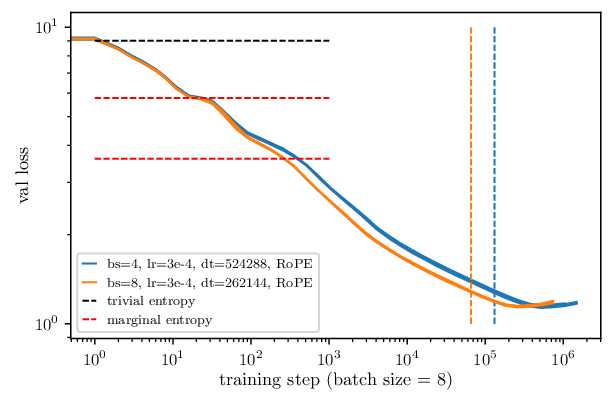

In [4]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 268435456
path = f'tinystories/trained/T{T}_rope/P{P}/'

depth = 12
de = 1024
nh = 16

bs = 4
for lr in ['3e-4']:
    for dt in [524288]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')

bs = 8
for lr in ['3e-4']:
    for dt in [262144]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P\approx 2^{29}$

1024 4 3e-4 4.0 tensor(1.0779) tensor(0.0039)
1024 8 3e-4 4.0 tensor(1.0708) tensor(0.0084)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=8$)')

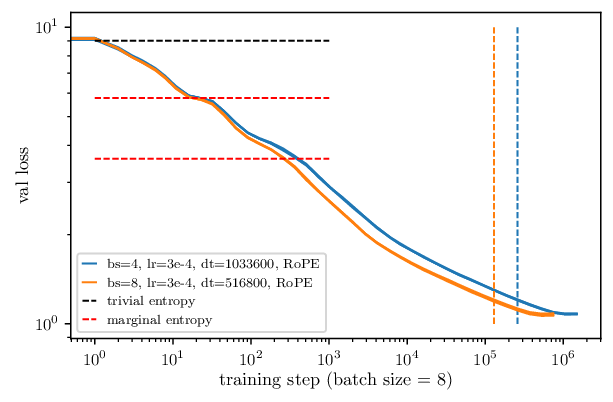

In [5]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 512
P = 529203200
path = f'tinystories/trained/T{T}_rope/P{P}/'

depth = 12
de = 1024
nh = 16

bs = 4
for lr in ['3e-4']:
    for dt in [1033600]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')

bs = 8
for lr in ['3e-4']:
    for dt in [516800]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)